# Image processing notebook: From overlap corrected to transmission 

### 00 - exp 1XX acquisition 00

##  Initial settings

### Import libraries
Import all the required libraries

In [1]:
import sys
sys.path.append(r'..\01_Functions')
from step_functions import *
from dict_functions import *
from proc_functions import *
from img_functions import *
%matplotlib inline

### Select directories
Select the source directory. This directory is where the images **after** the overlap correction were saved.
Select the destination directory. Here is where the transmission images are going to be saved.

In [2]:
# %load select_directory('src_dir')
src_dir = r"J:\900 Varia\2021\000_tony_data\03_Processed_step_by_step\00_Overlap_correction\exp1XX"

In [3]:
# %load select_directory('dst_dir')
dst_dir = r"J:\900 Varia\2021\000_tony_data\03_Processed_step_by_step\01_New_transmission_results"

### Select folders to process

In [4]:
stack_dict = prep_stack_dict(src_dir)
for key in stack_dict.keys():
    print(key)

00_ob
01_so_ref
02_exp102_00
02_exp102_01
02_exp102_02
02_exp102_03
02_exp102_04
03_ob_end


In [5]:
ref_folder = ['01_so_ref']
proc_folder = ['02_exp102_00']

## TEST processing for reference images

### Build the reference images dictionary 
keep_acq_numb: amount of acquisition folders to process. this is a test so we want to so it fast. thus, we limit the amount of data <br>
In case you want to get an image _(array, header)_ in the dictionary, follow the format:<br>

`test = extract_img_dict(exp_test_dict, proc_folder[0], img_number = 50)`<br>
"variable" = function("dictionary name", "key/folder", "acq_number = 0", "img_number = 50")

**_To visualize the image_** (a tuple with an array in position 0 and a header in position 1, you require the next instruction:<br>

`show_img(test[0])
test[1]` # to show the header of that image

In [6]:
ref_test_dict, ref_test_param = testing_mode_step (src_dir, proc_folder = ref_folder, keep_acq_numb = 1)

Reading Images: 100%|████████████████████████████| 3/3 [00:02<00:00,  1.38it/s]


### Pre-processing sequence with parameters
The pre-processing sequence refers to any sequence with their respective parameters that emphasize on modifying or enhancing the image (**usually filters**). In this step you can also perform an averaging of all the acquisitions `stack_averaging`, a step binning of the aquisitions `binning_acquisitions`, and/or a step binning of the frames `binning_frames`.

**The image processing (SBKG, registration, scrubbing, and/or TFC should be done in the processing step.**

**NOTE: The order of the functions in the sequence matters**, but not the order of the parameters, you can also include alien parameters, this will not affect the process.

In [7]:
pre_proc_seq = [outlier_removal, stack_averaging]
add_to_dict(ref_test_param,['threshold'], [0])

In [8]:
ref_test_dict = pre_processing_step (ref_test_dict, pre_proc_seq, param_dict = ref_test_param)

Processing Filetring : 100%|█████████████████████| 1/1 [00:00<00:00,  2.52it/s]


### Processing sequence and variables to obtain the referenceimages used in the TFC

In [9]:
proc_seq = [scrubbing_correction_dict, SBKG_correction_dict]

In [10]:
BB_mask = get_img(src_dir + '/bb_mask_ref_full.fits')
add_to_dict(ref_test_param,['BB_mask'], [BB_mask])

In [11]:
ref_test_dict = processing_step (ref_test_dict, proc_seq, param_dict = ref_test_param)

Processing SBKG Correction: 100%|████████████████| 1/1 [00:19<00:00, 19.44s/it]


### Get NCA
There will be displacements in the experiment images, for this reason, it is better to get the `nca` from the reference image.

In [12]:
# %load select_rois(ref_img_TFC[0], list_rois = ['nca'])
nca = [408, 399, 43, 10]

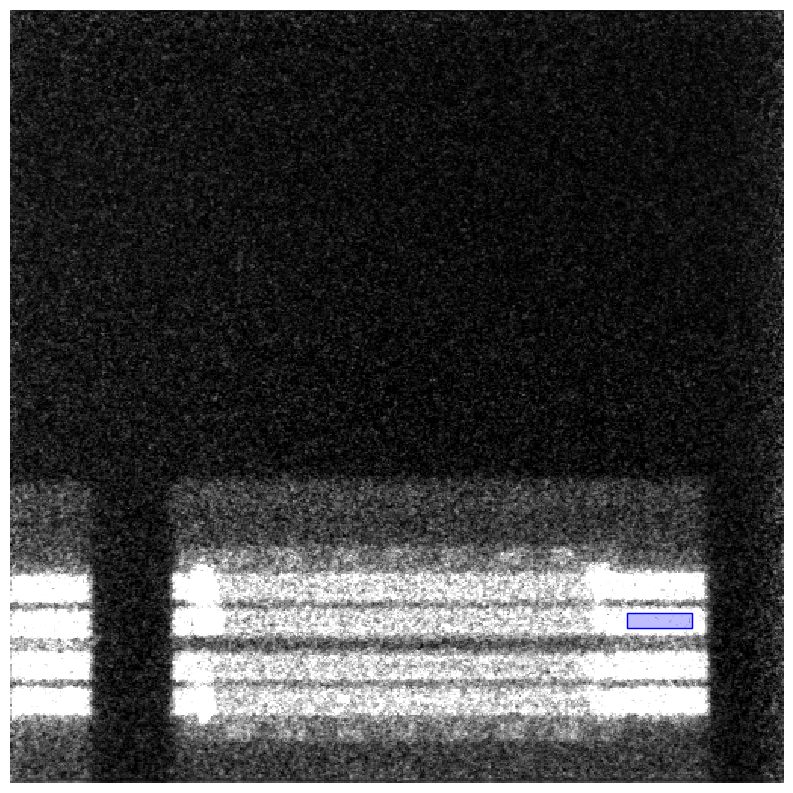

In [13]:
ref_img = extract_img_dict(ref_test_dict, ref_folder[0], img_number = 50)
show_img_rois(ref_img[0], dr = [(nca, 'blue')])

### Save the acquisition 
In imageJ you can create the image for the registration with this saved acquisition 

In [ ]:
dst_dir_test = dst_dir + '/imgs_4_registration_ref'
saving_step (ref_test_dict, dst_dir_test, img_name = 'ref_4_reg')

## TEST processing for experiment images

In [14]:
exp_test_dict, exp_test_param = testing_mode_step (src_dir, proc_folder = proc_folder, keep_acq_numb= 1)

Reading Images: 100%|████████████████████████████| 3/3 [00:01<00:00,  2.17it/s]


The pre processing sequence will not change. It will be the same as the one we used for the reference. Except if there is some averaging requirements

In [15]:
pre_proc_seq = [outlier_removal, stack_averaging]
add_to_dict(exp_test_param,['threshold'], [0])

In [16]:
exp_test_dict = pre_processing_step (exp_test_dict, pre_proc_seq, param_dict = exp_test_param)

Processing Filetring : 100%|█████████████████████| 1/1 [00:00<00:00,  2.57it/s]


### Processing sequence and variables (scrubbing and SBKG)

In [17]:
proc_seq = [scrubbing_correction_dict, SBKG_correction_dict]

In [18]:
BB_mask = get_img(src_dir + '/bb_mask_exp_full.fits')
add_to_dict(exp_test_param,['BB_mask'], [BB_mask])

In [19]:
exp_test_dict = processing_step (exp_test_dict, proc_seq, param_dict = exp_test_param)

Processing SBKG Correction: 100%|████████████████| 1/1 [00:23<00:00, 23.70s/it]


### Displacement correction
For this specific experiment, there is just a y-axis displacement. Therefore, `dof = ['ty']`

We also knew previously the ROIs of the regions for the correction `reg_rois_list`. Otherwise, we would have to select them in an extra step

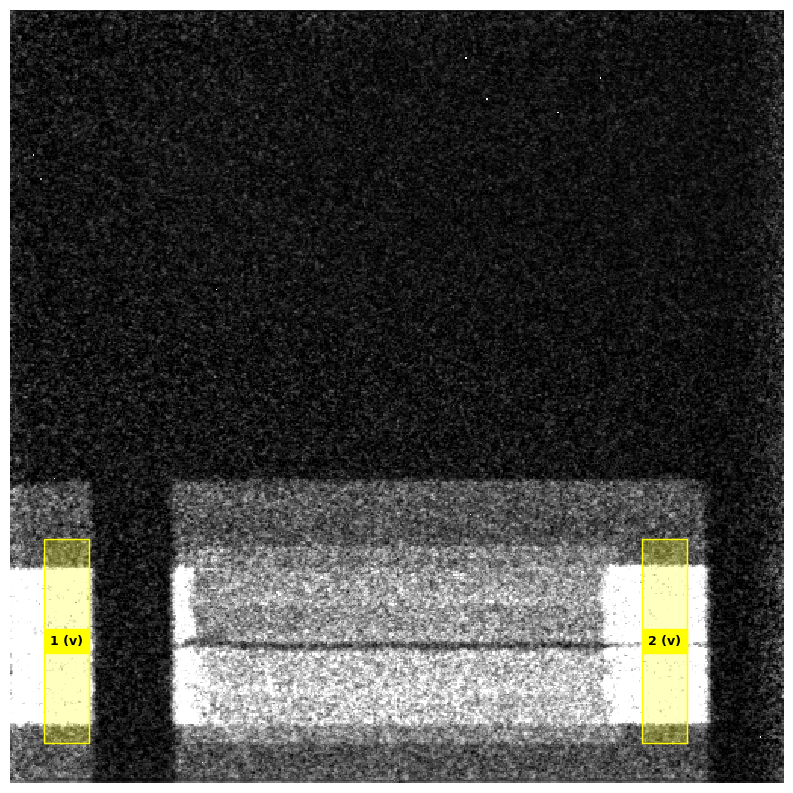

In [20]:
reg_img = get_img(src_dir + '/ref_reg_img.fits')
reg_rois_list = [([22, 350, 30, 135], 'v'), ([418, 350, 30, 135], 'v')]

img = extract_img_dict(exp_test_dict, proc_folder[0], img_number = 15)
show_img_rois(img[0], dr = [(reg_rois_list, 'yellow')])

check_ref = extract_img_dict(ref_test_dict, ref_folder[0], img_number = 50)

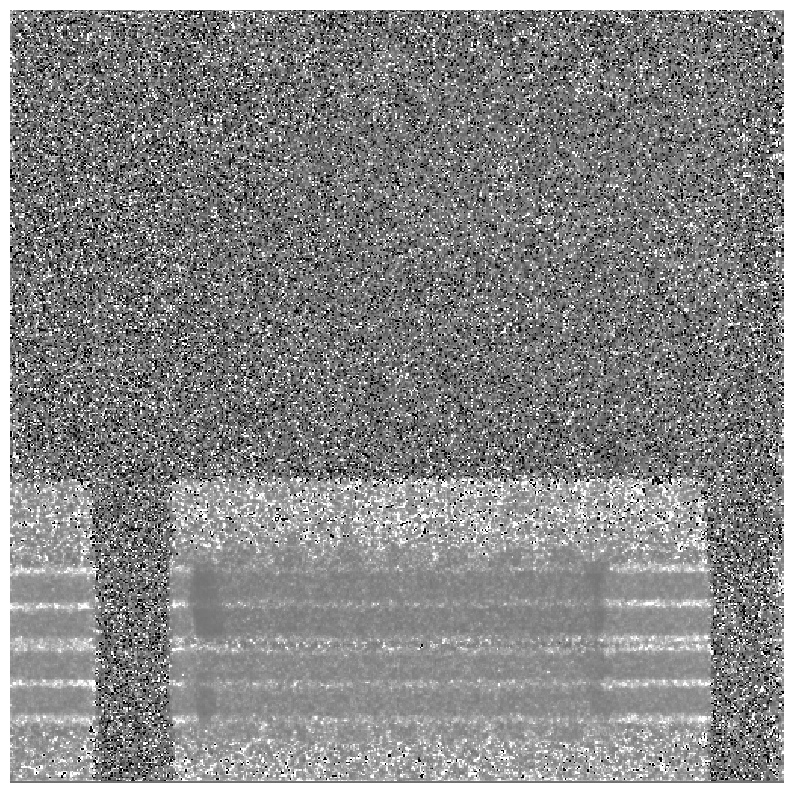

[[1.     0.     0.5666]
 [0.     1.     0.    ]
 [0.     0.     1.    ]]


In [21]:
disp = float(0.5666)
M = np.array([[1,0,disp], [0,1,0], [0,0,1]])
img_reg_corr, M = img_registration (img, reg_img, reg_rois_list = reg_rois_list, dof=['ty'],M=M)
show_img(img_reg_corr[0]/check_ref[0], cmap = 'gray')
print(M)

In [22]:
proc_seq = [image_registration_dict]

In [23]:
add_to_dict(exp_test_param,['M', 'dof'], [M, ['ty']])

In [24]:
exp_test_dict = processing_step (exp_test_dict, proc_seq, param_dict = exp_test_param)

Processing Image Registration: 100%|█████████████| 1/1 [00:01<00:00,  1.27s/it]


### TFC and final transission

In [25]:
proc_seq = [TFC_correction_dict]

In [26]:
add_to_dict(exp_test_param,['nca', 'use_ref', 'ref_dict'], [nca, True, ref_test_dict])

In [27]:
exp_test_dict = processing_step (exp_test_dict, proc_seq, param_dict = exp_test_param)

Processing TFC Correction: 100%|█████████████████| 1/1 [00:00<00:00,  3.93it/s]


In [ ]:
#dst_dir_test = dst_dir + '/exp1XX_avg_test'
#saving_step (exp_test_dict, dst_dir_test, img_name = 'exp102_avg_testing')

## Reference Full Processing

In [28]:
ref_dict, ref_param = reading_step (src_dir, proc_folder = ref_folder)

Reading Images: 100%|████████████████████████████| 3/3 [00:23<00:00,  7.69s/it]


In [29]:
pre_proc_seq = [outlier_removal, stack_averaging]
add_to_dict(ref_param,['threshold'], [0])

In [30]:
ref_dict = pre_processing_step (ref_dict, pre_proc_seq, param_dict = ref_param)

Processing Filetring : 100%|█████████████████████| 6/6 [00:02<00:00,  2.34it/s]


In [31]:
proc_seq = [scrubbing_correction_dict, SBKG_correction_dict]

In [32]:
BB_mask = get_img(src_dir + '/bb_mask_ref_full.fits')
add_to_dict(ref_param,['BB_mask'], [BB_mask])

In [33]:
ref_dict = processing_step (ref_dict, proc_seq, param_dict = ref_param)

Processing SBKG Correction: 100%|████████████████| 1/1 [00:18<00:00, 18.60s/it]


In [34]:
proc_seq = [TFC_correction_dict]
add_to_dict(ref_param,['nca', 'use_ref', 'ref_dict'], [nca, False, ref_dict])

In [ ]:
#dst_dir_test = dst_dir + '/00_Ref_dict_processed'
#saving_step (ref_dict, dst_dir_test, img_name = 'so_ref_image')

## Store reference dictionary and parameters

In [35]:
%store ref_dict

Stored 'ref_dict' (dict)


### Update the reference dictionary

In [36]:
exp_param = exp_test_param
add_to_dict(exp_param,['ref_dict'], [ref_dict])

In [37]:
%store exp_param

Stored 'exp_param' (dict)
